Dit notebook is om de de effecten van de preprocessingen stappen op een enkel spectrum te visualiseren.

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)


from utils.baseline_correction_functions import BaselineCorrector
from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor, plot_single_spectrum
from utils.normalization_functions import Normalizer
from utils.saturation_functions import apply_voigt_saturation_correction

In [12]:
dataloader = LibsDataLoader(data_directory='data')
preprocessor = LibsDataPreprocessor()
corrector = BaselineCorrector()

In [13]:
df = dataloader.load_all_measurements_no_rounding()

MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5
Processing file 101/316: 2024-11-05T14-16-52_nr-1

In [14]:
non_feature_cols = ['tire_number', 'origin', 'measurement_id']
print(f"Non-feature columns: {non_feature_cols}")

# Get numeric columns (wavelength data)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]

Non-feature columns: ['tire_number', 'origin', 'measurement_id']


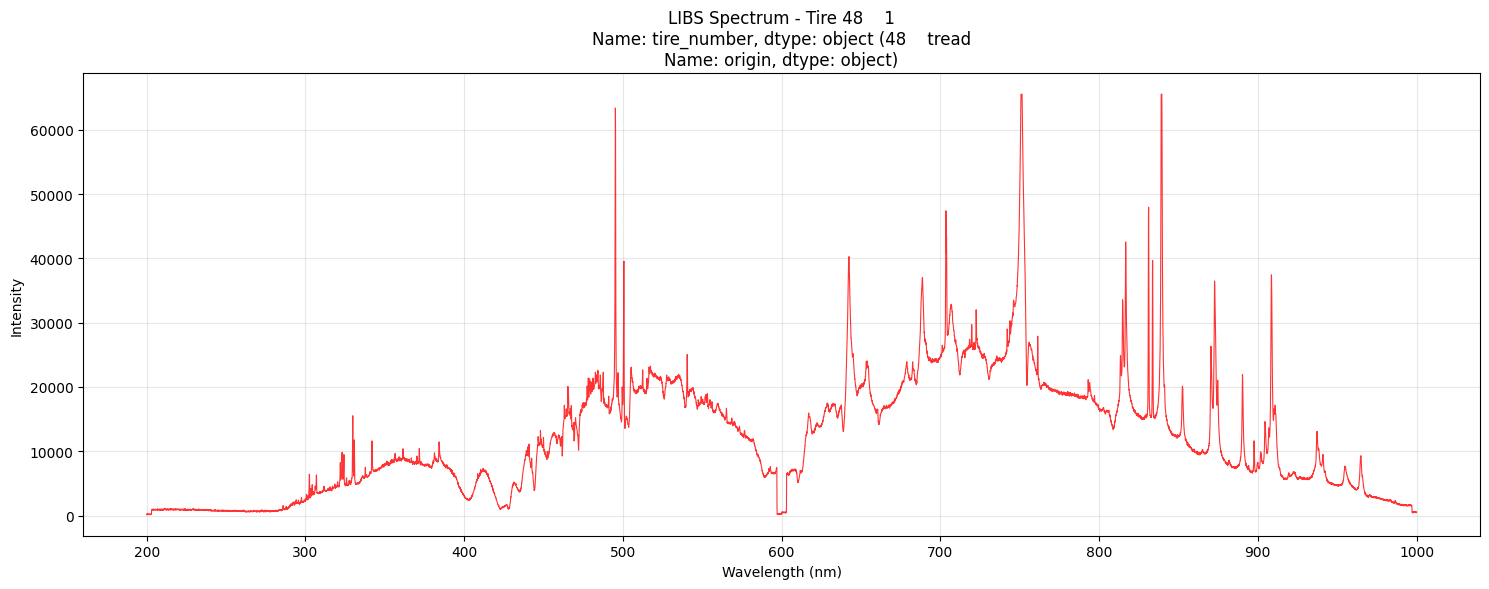

In [26]:
row_series = df.loc[48]
single_tire_data = row_series.to_frame().T
# single_tire_data = df.loc[47]

# Extract wavelength data - use the actual column names
wavelength_values = [float(col) for col in wavelength_columns]
intensity_values = [single_tire_data[col] for col in wavelength_columns]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelength_values, intensity_values, linewidth=0.8, alpha=0.8, color='red')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title(f'LIBS Spectrum - Tire {single_tire_data["tire_number"]} ({single_tire_data["origin"]})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from utils.saturation_functions import run_complete_saturation_analysis, apply_voigt_saturation_correction, plot_voigt_correction_examples

single_tire_data_voigt = apply_voigt_saturation_correction(
    df=single_tire_data,
)


🔧 Voigt Profile Saturation Correction
Total measurements: 1
Saturated measurements: 1
Processing measurements: 1
Saturation threshold: 65535
Minimum peak width: 3
Progress: 1/1 (100.0%)

📊 Correction Summary:
------------------------------
Measurements processed: 1
Measurements corrected: 1
Success rate: 100.0%
Total peaks found: 2
Total peaks corrected: 2
Peak correction rate: 100.0%

Intensity ranges:
Original max: 65,535
Corrected max: 79,986
Max increase: 1.22x


In [ ]:
plot_voigt_correction_examples(single_tire_data, single_tire_data_voigt, n_examples=1)

In [ ]:
from utils.baseline_correction_functions import apply_baseline_correction_to_dataframe

single_tire_data_baseline_corrected = apply_baseline_correction_to_dataframe(
    df=single_tire_data_voigt)

plot_single_spectrum(
    df=single_tire_data_baseline_corrected,)


In [ ]:
from utils.normalization_functions import Normalizer
normalizer = Normalizer()
single_tire_data_normalized = normalizer.apply_standard_normal_variate_on_dataframe(
    df=single_tire_data_baseline_corrected)

# Plot the normalized spectrum
plot_single_spectrum(
    df=single_tire_data_normalized)